In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [8]:
data_str = 'vin_pax_zyx_act_front'
pro_str = 'vin_front_correctloader'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim_array = [4,6,8,10,12,14,16,18,20,22,24]
BN_flag = True
dropout_flag = True
epochs = int(10000)
lr = 1e-4
eps = 3
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 0

dir_list = [
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch0_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1518',
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch0_major/y_ch0_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1530',
]



In [9]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)



In [10]:
total_sum_sq = 0.0
total_sum = 0.0
n_total = 0

for images, _ in whole_data_loader:
    images = images.to(torch.float32)
    total_sum += (images).sum().item()
    total_sum_sq += (images ** 2).sum().item()
    n_total += images.numel()

mean_square = total_sum_sq / n_total
mean = total_sum / n_total
print("Mean square of all pixels:", mean_square)

joblib.dump(mean_square,'../results/vin_front_mean_square.pkl')

Mean square of all pixels: 0.010358415446743355


['../results/vin_front_mean_square.pkl']

In [ ]:
train_loss_across_latentdim = []
val_loss_across_latentdim = []

for  latent_dim in latent_dim_array:
        
    now = datetime.now()

    time_str = now.strftime("%Y%m%d_%H%M")

    result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
    os.makedirs(result_dir, exist_ok=True)

    # Train AE
    ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

    ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)

    train_loss_across_latentdim.append(train_losses[-1])
    val_loss_across_latentdim.append(val_losses[-1])
    
    latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

    if isinstance(group_id, torch.Tensor):
        group_id = group_id.cpu().numpy()
    elif isinstance(group_id, list):
        group_id = torch.cat(group_id).cpu().numpy()

    latents_2d = UMAP_train(latents, result_dir)

    DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latents, eps=eps, min_samples=min_samples, result_dir=result_dir)

    kmeans, kmeans_labels = kmeans_cluster(latents, num_clusters=kmeans_num_clusters, result_dir=result_dir)

    fig = umap_2Dplot(latents_2d, 0,1,group_id)
    fig.savefig(os.path.join(result_dir, 'umap_2d_grouplabels.png'))

    fig = cluster_2Dplot(latents, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_latent01_labels.png'))
    
    fig = cluster_2Dplot(latents, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_latent01_labels.png'))

    fig = cluster_2Dplot(latents_2d, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_umap2d_labels.png'))
    
    fig = cluster_2Dplot(latents_2d, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_umap2d_labels.png'))


Epoch 200/10000, Train Loss: 0.0041, Val Loss: 0.0046
Epoch 400/10000, Train Loss: 0.0038, Val Loss: 0.0047
Epoch 600/10000, Train Loss: 0.0036, Val Loss: 0.0048
Epoch 800/10000, Train Loss: 0.0036, Val Loss: 0.0049
Epoch 1000/10000, Train Loss: 0.0034, Val Loss: 0.0050
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0017, max: 0.7770, mean: 0.0553, std: 0.0465
Epoch 1200/10000, Train Loss: 0.0033, Val Loss: 0.0050
Epoch 1400/10000, Train Loss: 0.0032, Val Loss: 0.0051
Epoch 1600/10000, Train Loss: 0.0032, Val Loss: 0.0051
Epoch 1800/10000, Train Loss: 0.0032, Val Loss: 0.0052
Epoch 2000/10000, Train Loss: 0.0031, Val Loss: 0.0052
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0001, max: 0.8555, mean: 0.0543, std: 0.0479
Epoch 2200/10000, Train Loss: 0.0031, Val Loss: 0.0053
Epoch 2400/10000, Train Loss: 0.0031, Val Loss: 0.0053
Epoch 2600/10000, Train Loss: 0.0030, Val Loss: 0.0054
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.0038, Val Loss: 0.0042
Epoch 400/10000, Train Loss: 0.0034, Val Loss: 0.0043
Epoch 600/10000, Train Loss: 0.0031, Val Loss: 0.0044
Epoch 800/10000, Train Loss: 0.0029, Val Loss: 0.0046
Epoch 1000/10000, Train Loss: 0.0028, Val Loss: 0.0047
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0000, max: 0.6887, mean: 0.0540, std: 0.0512
Epoch 1200/10000, Train Loss: 0.0027, Val Loss: 0.0047
Epoch 1400/10000, Train Loss: 0.0026, Val Loss: 0.0048
Epoch 1600/10000, Train Loss: 0.0025, Val Loss: 0.0049
Epoch 1800/10000, Train Loss: 0.0024, Val Loss: 0.0049
Epoch 2000/10000, Train Loss: 0.0024, Val Loss: 0.0050
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0000, max: 0.7090, mean: 0.0541, std: 0.0490
Epoch 2200/10000, Train Loss: 0.0024, Val Loss: 0.0050
Epoch 2400/10000, Train Loss: 0.0023, Val Loss: 0.0050
Epoch 2600/10000, Train Loss: 0.0023, Val Loss: 0.0051
Epoch 2

/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/autoencoders.py:97: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))


Epoch 5200/10000, Train Loss: 0.0020, Val Loss: 0.0052
Epoch 5400/10000, Train Loss: 0.0020, Val Loss: 0.0052
Epoch 5600/10000, Train Loss: 0.0020, Val Loss: 0.0053
Epoch 5800/10000, Train Loss: 0.0020, Val Loss: 0.0053
Epoch 6000/10000, Train Loss: 0.0020, Val Loss: 0.0053
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0000, max: 0.9770, mean: 0.0514, std: 0.0475
Epoch 6200/10000, Train Loss: 0.0020, Val Loss: 0.0053
Epoch 6400/10000, Train Loss: 0.0019, Val Loss: 0.0053
Epoch 6600/10000, Train Loss: 0.0019, Val Loss: 0.0053
Epoch 6800/10000, Train Loss: 0.0019, Val Loss: 0.0053
Epoch 7000/10000, Train Loss: 0.0019, Val Loss: 0.0053
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0000, max: 0.9826, mean: 0.0520, std: 0.0468
Epoch 7200/10000, Train Loss: 0.0019, Val Loss: 0.0054
Epoch 7400/10000, Train Loss: 0.0019, Val Loss: 0.0054
Epoch 7600/10000, Train Loss: 0.0019, Val Loss: 0.0053
Epo

...

Epoch 200/10000, Train Loss: 0.0027, Val Loss: 0.0031
Epoch 400/10000, Train Loss: 0.0021, Val Loss: 0.0033
Epoch 600/10000, Train Loss: 0.0018, Val Loss: 0.0034
Epoch 800/10000, Train Loss: 0.0017, Val Loss: 0.0036
Epoch 1000/10000, Train Loss: 0.0016, Val Loss: 0.0036
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0001, max: 0.5551, mean: 0.0520, std: 0.0534
Epoch 1200/10000, Train Loss: 0.0015, Val Loss: 0.0037
Epoch 1400/10000, Train Loss: 0.0014, Val Loss: 0.0037
Epoch 1600/10000, Train Loss: 0.0014, Val Loss: 0.0037
Epoch 1800/10000, Train Loss: 0.0014, Val Loss: 0.0037
Epoch 2000/10000, Train Loss: 0.0013, Val Loss: 0.0038
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0001, max: 0.5342, mean: 0.0528, std: 0.0526
Epoch 2200/10000, Train Loss: 0.0013, Val Loss: 0.0038
Epoch 2400/10000, Train Loss: 0.0013, Val Loss: 0.0038
Epoch 2600/10000, Train Loss: 0.0013, Val Loss: 0.0038
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.0026, Val Loss: 0.0030
Epoch 400/10000, Train Loss: 0.0020, Val Loss: 0.0032
Epoch 600/10000, Train Loss: 0.0018, Val Loss: 0.0033
Epoch 800/10000, Train Loss: 0.0016, Val Loss: 0.0034
Epoch 1000/10000, Train Loss: 0.0015, Val Loss: 0.0035
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0002, max: 0.6505, mean: 0.0527, std: 0.0524
Epoch 1200/10000, Train Loss: 0.0015, Val Loss: 0.0035
Epoch 1400/10000, Train Loss: 0.0014, Val Loss: 0.0036
Epoch 1600/10000, Train Loss: 0.0014, Val Loss: 0.0036
Epoch 1800/10000, Train Loss: 0.0014, Val Loss: 0.0036
Epoch 2000/10000, Train Loss: 0.0013, Val Loss: 0.0037
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0001, max: 0.6403, mean: 0.0522, std: 0.0507
Epoch 2200/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2400/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2600/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.0025, Val Loss: 0.0029
Epoch 400/10000, Train Loss: 0.0020, Val Loss: 0.0031
Epoch 600/10000, Train Loss: 0.0017, Val Loss: 0.0033
Epoch 800/10000, Train Loss: 0.0016, Val Loss: 0.0034
Epoch 1000/10000, Train Loss: 0.0015, Val Loss: 0.0034
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0003, max: 0.5720, mean: 0.0510, std: 0.0517
Epoch 1200/10000, Train Loss: 0.0014, Val Loss: 0.0035
Epoch 1400/10000, Train Loss: 0.0014, Val Loss: 0.0035
Epoch 1600/10000, Train Loss: 0.0013, Val Loss: 0.0035
Epoch 1800/10000, Train Loss: 0.0013, Val Loss: 0.0036
Epoch 2000/10000, Train Loss: 0.0013, Val Loss: 0.0036
Input stats — min: 0.0000, max: 0.9486, mean: 0.0563, std: 0.0789
Reconstruction stats — min: 0.0002, max: 0.6707, mean: 0.0529, std: 0.0529
Epoch 2200/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2400/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2600/10000, Train Loss: 0.0013, Val Loss: 0.0037
Epoch 2

In [ ]:
joblib.dump(train_loss_across_latentdim, os.path.join('../results', 'train_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
joblib.dump(val_loss_across_latentdim, os.path.join('../results', 'val_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
    

['../results/val_loss_across_latentdimvin_front_ch1_ps32_latdim_24_20251002_0648.pkl']

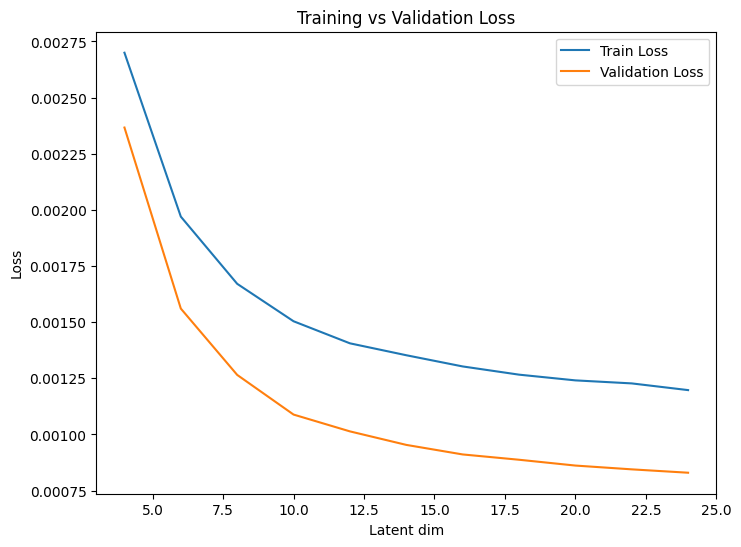

In [ ]:
# Plot training and validation loss
fig = plt.figure(figsize=(8, 6))
plt.plot(latent_dim_array, train_loss_across_latentdim, label='Train Loss')
plt.plot(latent_dim_array, val_loss_across_latentdim, label='Validation Loss')
plt.xlabel('Latent dim')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
fig.savefig(os.path.join('../results', 'latent_dim_train_val_losses'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.png'))